РЕШЕНИЕ КРАЕВОЙ ЗАДАЧИ МЕТОДОМ СТРЕЛЬБЫ
С ПРОДОЛЖЕНИЕМ ПО ПАРАМЕТРУ α

=== СЦЕНАРИЙ 1: Решение с продолжением по параметру ===

=== ПОИСК РЕШЕНИЙ ДЛЯ ЗАДАННЫХ α ===

=== РЕШЕНИЕ МЕТОДОМ ПРОДОЛЖЕНИЯ ПО ПАРАМЕТРУ α ===
Шаг по α: 1.0
Диапазон: от 0.0 до 10.2

Шаг 1/11: α = 0.000
  Найдено: β1 = 2.500000, β2 = -6.000000

Шаг 2/11: α = 1.020
  Найдено: β1 = 2.946968, β2 = -6.994709

Шаг 3/11: α = 2.040
  Найдено: β1 = 3.333393, β2 = -7.861691

Шаг 4/11: α = 3.060
  Найдено: β1 = 3.637166, β2 = -8.552832

Шаг 5/11: α = 4.080
  Найдено: β1 = 3.866770, β2 = -9.084184

Шаг 6/11: α = 5.100
  Найдено: β1 = 4.039634, β2 = -9.491422

Шаг 7/11: α = 6.120
  Найдено: β1 = 4.171451, β2 = -9.807388

Шаг 8/11: α = 7.140
  Найдено: β1 = 4.273883, β2 = -10.056919

Шаг 9/11: α = 8.160
  Найдено: β1 = 4.355090, β2 = -10.257677

Шаг 10/11: α = 9.180
  Найдено: β1 = 4.420704, β2 = -10.422052

Шаг 11/11: α = 10.200
  Найдено: β1 = 4.474640, β2 = -10.558784

--- Решение для α = 0.0 ---
  Используется начальное п

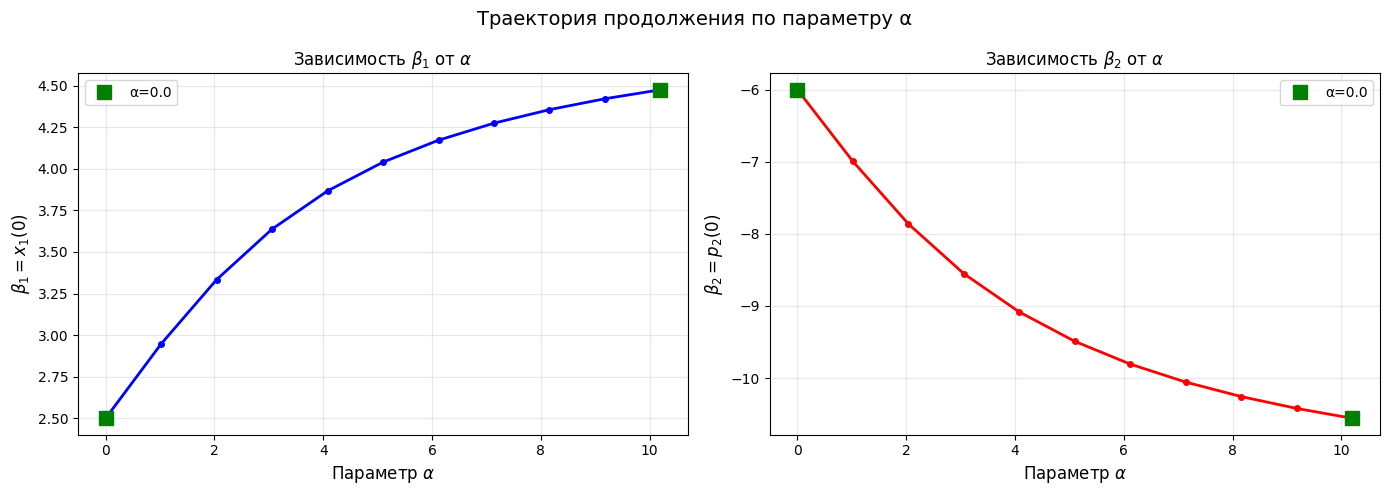

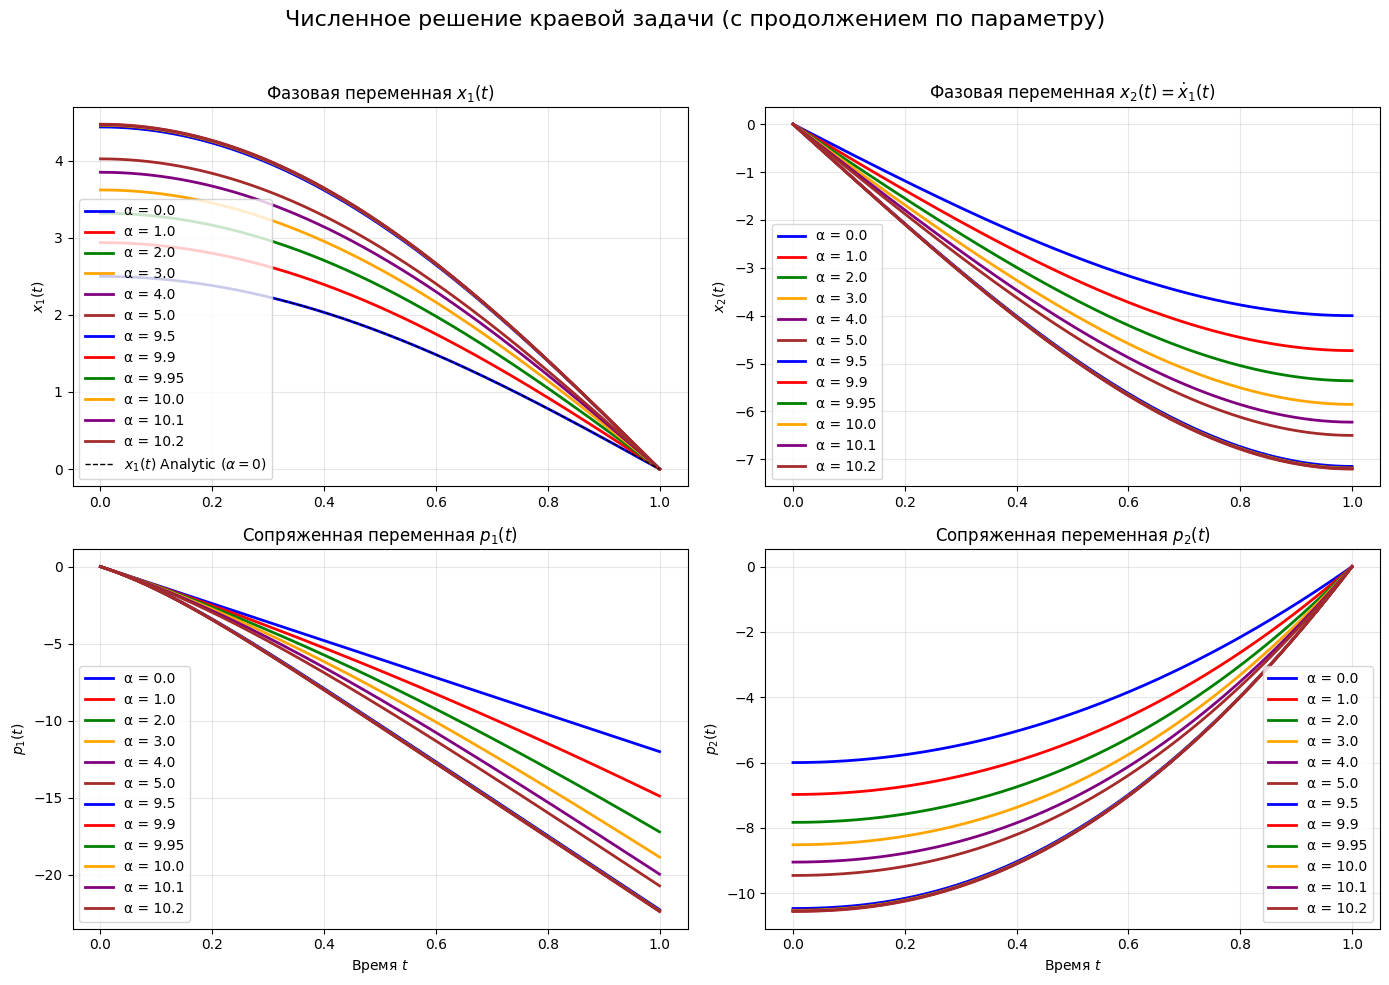



=== СЦЕНАРИЙ 2: Решение без продолжения (для сравнения) ===

=== ПОИСК РЕШЕНИЙ ДЛЯ ЗАДАННЫХ α ===

--- Решение для α = 0.0 ---
  β1 = 2.50000000, β2 = -6.00000000

--- Решение для α = 1.0 ---
  β1 = 2.93864159, β2 = -6.97612456

--- Решение для α = 2.0 ---
  β1 = 3.31978248, β2 = -7.83096113

--- Решение для α = 3.0 ---
  β1 = 3.62150844, β2 = -8.51691939

--- Решение для α = 4.0 ---
  β1 = 3.85104061, β2 = -9.04746879

--- Решение для α = 5.0 ---
  β1 = 4.02472449, β2 = -9.45600432

--- Решение для α = 9.5 ---
  β1 = 4.43873324, β2 = -10.46758842

--- Решение для α = 9.9 ---
  β1 = 4.45980827, β2 = -10.52103086

--- Решение для α = 9.95 ---
  β1 = 4.46233601, β2 = -10.52745655

--- Решение для α = 10.0 ---
  β1 = 4.46484106, β2 = -10.53382796

--- Решение для α = 10.1 ---
  β1 = 4.46978428, β2 = -10.54641061

--- Решение для α = 10.2 ---
  β1 = 4.47464021, β2 = -10.55878400

РЕЗУЛЬТАТЫ ВЫЧИСЛЕНИЙ

РЕЗУЛЬТАТЫ ДЛЯ α = 0.0
β1 = x1(0) ≈ 2.50000000, β2 = p2(0) ≈ -6.00000000
t          x1

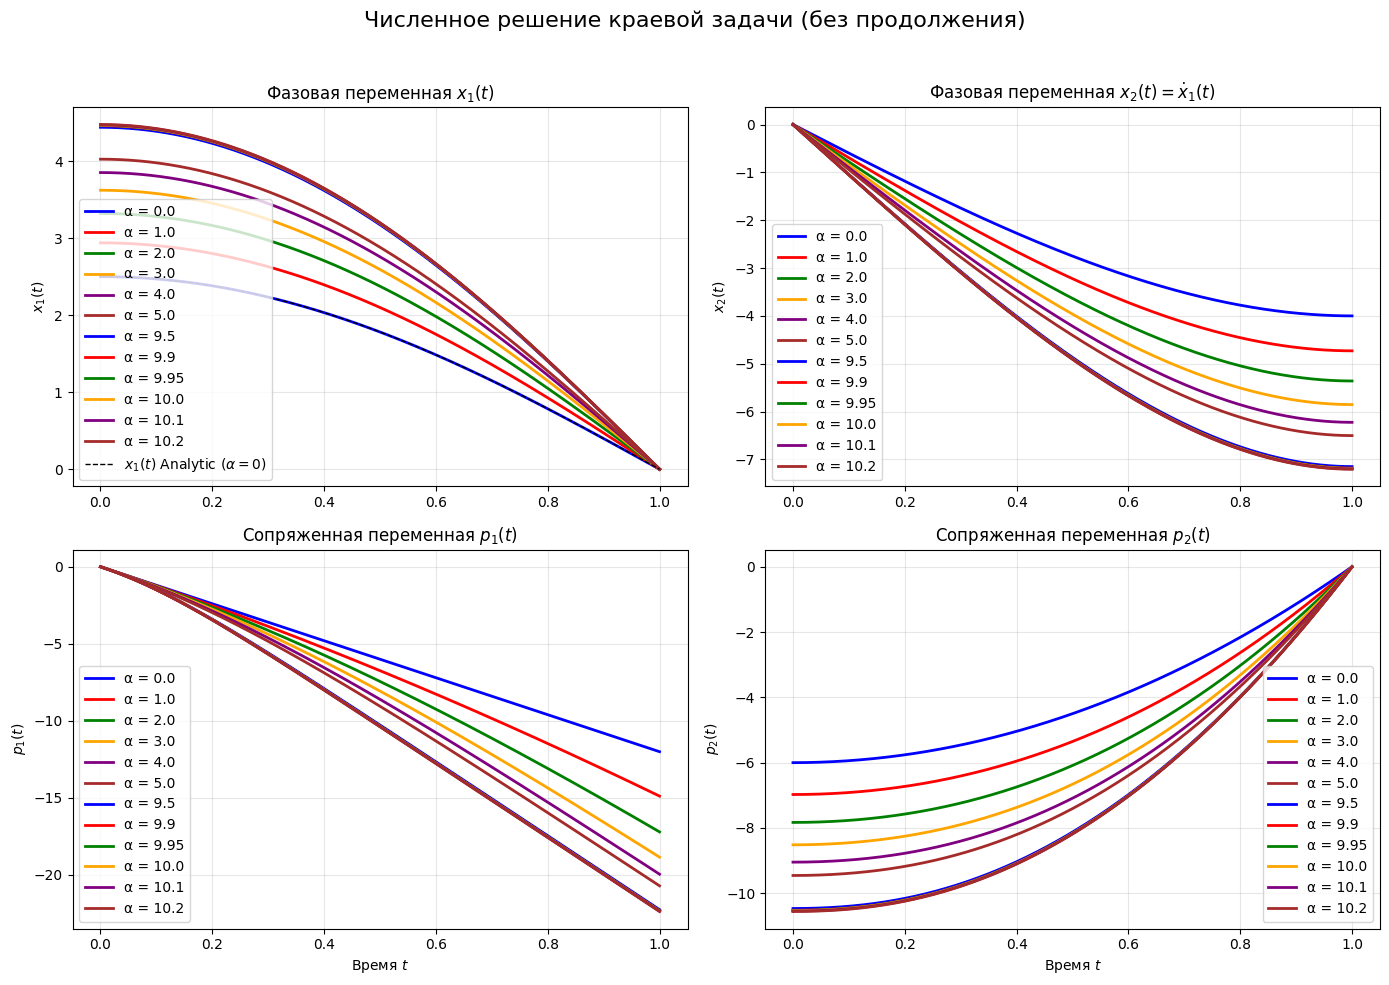



=== СЦЕНАРИЙ 3: Конкретный пример α=10 с использованием α=9 ===
Сначала находим решение для α=9...
Решение для α=9: β1 = 4.410068, β2 = -10.395265

Теперь используем это как начальное приближение для α=10...
Решение для α=10: β1 = 4.464841, β2 = -10.533828
Невязки граничных условий для α=10: x1(1) = 1.73e-14, p2(1) = 9.58e-16


In [8]:
import numpy as np
import matplotlib.pyplot as plt

class VariationalSolver:
    """
    Класс для решения краевой задачи оптимального управления
    методом стрельбы (RK4 + Метод Ньютона) с продолжением по параметру.
    """
    def __init__(self, alpha_values, lambda0=0.5, step_size=0.1, use_continuation=True):
        """
        Инициализация решателя.
        
        Parameters:
        -----------
        alpha_values : list или array
            Значения параметра α, для которых нужно найти решение
        lambda0 : float
            Начальное приближение для параметра λ (в вашей задаче не используется)
        step_size : float
            Шаг по параметру α для продолжения
        use_continuation : bool
            Использовать ли продолжение по параметру
        """
        self.alpha_values = sorted(alpha_values)  # Сортируем по возрастанию
        self.lambda0 = lambda0
        self.step_size = step_size
        self.use_continuation = use_continuation
        self.results = {}
        self.continuation_results = {}  # Для хранения всех решений при продолжении
        
    def ode_system(self, t, y, alpha):
        """
        ПРАВАЯ ЧАСТЬ СИСТЕМЫ ОДУ (10) С КОРРЕКТНОЙ ЭКСПОНЕНЦИАЛЬНОЙ ЗАВИСИМОСТЬЮ.
        y = [x1, x2, p1, p2]
        """
        x1, x2, p1, p2 = y
        
        # Уравнения системы
        f1 = x2                                # dx1/dt = x2
        f2 = p2                                # dx2/dt = p2 
        # КОРРЕКТНОЕ УРАВНЕНИЕ ИЗ ЗАДАЧИ: dp1/dt = -24 / (1 + e^(-alpha * t)) 
        f3 = -24.0 / (1.0 + np.exp(-alpha * t)) 
        f4 = -p1                               # dp2/dt = -p1
        return np.array([f1, f2, f3, f4])
        
    def integrate_system(self, beta1, beta2, alpha, n_points=1000):
        """
        Численное интегрирование системы методом Рунге-Кутты 4-го порядка.
        beta1 = x1(0), beta2 = p2(0).
        """
        t_start, t_end = 0.0, 1.0
        h = (t_end - t_start) / n_points
        t_values = np.linspace(t_start, t_end, n_points + 1)
        
        # Начальные условия: y(0) = [x1(0)=beta1, x2(0)=0, p1(0)=0, p2(0)=beta2]
        y_current = np.array([beta1, 0.0, 0.0, beta2])
        y_values = np.zeros((4, n_points + 1))
        y_values[:, 0] = y_current
        
        for i in range(n_points):
            t = t_values[i]
            
            # Коэффициенты Рунге-Кутты 4-го порядка
            k1 = h * self.ode_system(t, y_current, alpha)
            k2 = h * self.ode_system(t + h/2.0, y_current + k1/2.0, alpha)
            k3 = h * self.ode_system(t + h/2.0, y_current + k2/2.0, alpha)
            k4 = h * self.ode_system(t + h, y_current + k3, alpha)
            
            # Обновление значения (y_n+1)
            y_current += (k1 + 2.0*k2 + 2.0*k3 + k4) / 6.0
            y_values[:, i+1] = y_current
            
        return t_values, y_values

    def boundary_residuals(self, beta, alpha):
        """
        Вычисление невязок граничных условий F(β1, β2) = [x1(1), p2(1)].
        """
        beta1, beta2 = beta
        t_vals, y_vals = self.integrate_system(beta1, beta2, alpha)
        
        # Невязки, которые должны быть равны нулю
        residual1 = y_vals[0, -1] # x1(1)
        residual2 = y_vals[3, -1] # p2(1)
        return np.array([residual1, residual2])

    def compute_jacobian(self, beta, alpha, delta=1e-8):
        """
        Численное вычисление матрицы Якоби J(β) методом конечных разностей.
        """
        n = len(beta)
        J = np.zeros((n, n))
        F0 = self.boundary_residuals(beta, alpha)
        
        for j in range(n):
            beta_perturbed = beta.copy()
            beta_perturbed[j] += delta
            F_perturbed = self.boundary_residuals(beta_perturbed, alpha)
            J[:, j] = (F_perturbed - F0) / delta
        return J

    def solve_parameters(self, alpha, initial_guess=None, max_iter=20, tol=1e-8):
        """
        Метод Ньютона для поиска оптимальных параметров пристрелки.
        """
        if initial_guess is None:
            # Начальное приближение можно взять из решения для alpha=0 (там x1(0)=5, p2(0)=-6)
            initial_guess = np.array([5.0, -6.0]) 
            
        beta = initial_guess.copy()
        
        for iteration in range(max_iter):
            F = self.boundary_residuals(beta, alpha)
            residual_norm = np.linalg.norm(F)
            
            if residual_norm < tol:
                return beta
            
            J = self.compute_jacobian(beta, alpha)
            
            # Решение линейной системы J * d(beta) = -F
            try:
                delta_beta = np.linalg.solve(J, -F) 
            except np.linalg.LinAlgError:
                # В случае особенности используем псевдообратную матрицу
                delta_beta = -np.linalg.pinv(J) @ F
                
            # Обновление параметров: β^(k+1) = β^k + Δβ
            beta += delta_beta
            
        # Возвращаем лучшее найденное приближение
        return beta

    def solve_with_continuation(self, alpha_start=0.0, alpha_end=10.0):
        """
        Решение методом продолжения по параметру α с шагом step_size.
        Для каждого α используется решение с предыдущего шага как начальное приближение.
        """
        print(f"\n=== РЕШЕНИЕ МЕТОДОМ ПРОДОЛЖЕНИЯ ПО ПАРАМЕТРУ α ===")
        print(f"Шаг по α: {self.step_size}")
        print(f"Диапазон: от {alpha_start} до {alpha_end}")
        
        # Генерируем последовательность α с заданным шагом
        num_steps = int((alpha_end - alpha_start) / self.step_size) + 1
        alphas_continuation = np.linspace(alpha_start, alpha_end, num_steps)
        
        # Начальное приближение для α=0 (аналитическое решение)
        current_beta = np.array([5.0, -6.0])  # Для α=0: x1(0)=5, p2(0)=-6
        
        for i, alpha in enumerate(alphas_continuation):
            print(f"\nШаг {i+1}/{num_steps}: α = {alpha:.3f}")
            
            if i == 0:
                # Для первого α используем известное начальное приближение
                beta_opt = self.solve_parameters(alpha, initial_guess=current_beta)
            else:
                # Для последующих α используем решение с предыдущего шага
                beta_opt = self.solve_parameters(alpha, initial_guess=current_beta)
            
            # Сохраняем решение
            self.continuation_results[alpha] = beta_opt
            
            # Обновляем текущее приближение для следующего шага
            current_beta = beta_opt.copy()
            
            # Выводим прогресс
            print(f"  Найдено: β1 = {beta_opt[0]:.6f}, β2 = {beta_opt[1]:.6f}")
        
        return self.continuation_results

    def solve_for_target_alphas(self):
        """
        Найти решения для целевых значений α, используя продолжение.
        """
        print(f"\n=== ПОИСК РЕШЕНИЙ ДЛЯ ЗАДАННЫХ α ===")
        
        # Если используем продолжение, сначала строим траекторию
        if self.use_continuation:
            # Определяем диапазон для продолжения
            alpha_min = min(self.alpha_values)
            alpha_max = max(self.alpha_values)
            
            # Строим траекторию продолжения
            self.solve_with_continuation(alpha_start=alpha_min, alpha_end=alpha_max)
        
        # Теперь находим решения для целевых α
        for alpha in self.alpha_values:
            print(f"\n--- Решение для α = {alpha} ---")
            
            if self.use_continuation and alpha in self.continuation_results:
                # Используем решение из продолжения как начальное приближение
                initial_guess = self.continuation_results[alpha]
                print(f"  Используется начальное приближение из продолжения")
            else:
                # Ищем ближайшее меньшее α в результатах продолжения
                initial_guess = self._find_closest_initial_guess(alpha)
            
            # Решаем методом Ньютона
            beta_opt = self.solve_parameters(alpha, initial_guess=initial_guess)
            beta1_opt, beta2_opt = beta_opt
            
            # Вычисляем полную траекторию
            t_vals, y_vals = self.integrate_system(beta1_opt, beta2_opt, alpha)
            
            # Сохраняем результаты
            self.results[alpha] = {
                'beta1': beta1_opt,
                'beta2': beta2_opt,
                'time': t_vals,
                'x1': y_vals[0],
                'x2': y_vals[1],
                'p1': y_vals[2],
                'p2': y_vals[3],
                'final_x1': y_vals[0, -1],
                'final_p2': y_vals[3, -1],
                'initial_guess_used': initial_guess
            }
            
            print(f"  β1 = {beta1_opt:.8f}, β2 = {beta2_opt:.8f}")
            
        return self.results

    def _find_closest_initial_guess(self, alpha):
        """
        Найти ближайшее начальное приближение для заданного α.
        Ищет решение для ближайшего меньшего α в результатах продолжения.
        """
        if not self.continuation_results:
            # Если нет результатов продолжения, используем решение для α=0
            return np.array([5.0, -6.0])
        
        # Ищем ближайшее α из результатов продолжения
        available_alphas = sorted(self.continuation_results.keys())
        
        # Ищем ближайшее меньшее α
        closest_alpha = None
        for a in reversed(available_alphas):
            if a <= alpha:
                closest_alpha = a
                break
        
        if closest_alpha is not None:
            print(f"  Используется решение для α={closest_alpha} как начальное приближение")
            return self.continuation_results[closest_alpha].copy()
        else:
            # Если не нашли меньшего, берем наименьшее доступное
            print(f"  Используется решение для α={available_alphas[0]} как начальное приближение")
            return self.continuation_results[available_alphas[0]].copy()

    def display_results(self, n_points_table=6):
        """
        Вывод результатов вычислений в формате таблиц.
        """
        print("\n" + "="*85)
        print("РЕЗУЛЬТАТЫ ВЫЧИСЛЕНИЙ")
        
        for alpha in self.alpha_values:
            res = self.results[alpha]
            
            print("\n" + "="*85)
            print(f"РЕЗУЛЬТАТЫ ДЛЯ α = {alpha}")
            print(f"β1 = x1(0) ≈ {res['beta1']:.8f}, β2 = p2(0) ≈ {res['beta2']:.8f}")
            print("="*85)
            
            # Индексы для вывода точек
            indices = np.linspace(0, len(res['time']) - 1, n_points_table, dtype=int)
            
            print(f"{'t':<10} {'x1(t)':<15} {'x2(t)':<15} {'p1(t)':<15} {'p2(t)':<15}")
            print("-" * 75)
            
            for i in indices:
                t = res['time'][i]
                x1 = res['x1'][i]
                x2 = res['x2'][i]
                p1 = res['p1'][i]
                p2 = res['p2'][i]
                print(f"{t:.6f} {x1:.8f} {x2:.8f} {p1:.8f} {p2:.8f}")
            print("-" * 75)
            print("Проверка граничных условий:")
            print(f"x1(1) = {res['final_x1']:.2e} (должно быть 0)")
            print(f"p2(1) = {res['final_p2']:.2e} (должно быть 0)")

    def plot_continuation_path(self):
        """
        Визуализация траектории продолжения по параметру α.
        """
        if not self.continuation_results:
            print("Нет данных продолжения для визуализации.")
            return
        
        alphas = sorted(self.continuation_results.keys())
        beta1_vals = [self.continuation_results[a][0] for a in alphas]
        beta2_vals = [self.continuation_results[a][1] for a in alphas]
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # График β1(α)
        axes[0].plot(alphas, beta1_vals, 'b-o', linewidth=2, markersize=4)
        axes[0].set_xlabel(r'Параметр $\alpha$', fontsize=12)
        axes[0].set_ylabel(r'$\beta_1 = x_1(0)$', fontsize=12)
        axes[0].set_title(r'Зависимость $\beta_1$ от $\alpha$')
        axes[0].grid(True, alpha=0.3)
        
        # График β2(α)
        axes[1].plot(alphas, beta2_vals, 'r-o', linewidth=2, markersize=4)
        axes[1].set_xlabel(r'Параметр $\alpha$', fontsize=12)
        axes[1].set_ylabel(r'$\beta_2 = p_2(0)$', fontsize=12)
        axes[1].set_title(r'Зависимость $\beta_2$ от $\alpha$')
        axes[1].grid(True, alpha=0.3)
        
        # Отметим целевые α
        for alpha in self.alpha_values:
            if alpha in self.continuation_results:
                beta1 = self.continuation_results[alpha][0]
                beta2 = self.continuation_results[alpha][1]
                axes[0].plot(alpha, beta1, 'gs', markersize=10, label=f'α={alpha}' if alpha == self.alpha_values[0] else "")
                axes[1].plot(alpha, beta2, 'gs', markersize=10, label=f'α={alpha}' if alpha == self.alpha_values[0] else "")
        
        axes[0].legend()
        axes[1].legend()
        plt.suptitle('Траектория продолжения по параметру α', fontsize=14)
        plt.tight_layout()
        plt.show()

    def plot_solutions(self):
        """
        Визуализация полученных решений для всех 4 компонент.
        """
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']
        
        # Аналитическое решение для alpha=0 (x1(t) = t^4 - 6t^2 + 5)
        t_analytic = np.linspace(0, 1, 100)
        x1_analytic = 0.5*t_analytic**4 - 3*t_analytic**2 + 5/2
        
        for idx, alpha in enumerate(self.alpha_values):
            res = self.results[alpha]
            color = colors[idx % len(colors)]
            t = res['time']
            
            # x1(t)
            axes[0,0].plot(t, res['x1'], color=color, linewidth=2, label=f'α = {alpha}')
            # x2(t) = x'(t)
            axes[0,1].plot(t, res['x2'], color=color, linewidth=2, label=f'α = {alpha}')
            # p1(t)
            axes[1,0].plot(t, res['p1'], color=color, linewidth=2, label=f'α = {alpha}')
            # p2(t)
            axes[1,1].plot(t, res['p2'], color=color, linewidth=2, label=f'α = {alpha}')
        
        # Добавление аналитического решения на график x1(t) для сравнения
        if 0.0 in self.alpha_values:
             axes[0,0].plot(t_analytic, x1_analytic, color='black', linestyle='--', 
                            linewidth=1, label=r'$x_1(t)$ Analytic ($\alpha=0$)')

        # Настройка графиков
        axes[0,0].set_title(r'Фазовая переменная $x_1(t)$')
        axes[0,0].set_ylabel(r'$x_1(t)$')
        axes[0,0].legend()

        axes[0,1].set_title(r'Фазовая переменная $x_2(t) = \dot{x}_1(t)$')
        axes[0,1].set_ylabel(r'$x_2(t)$')
        axes[0,1].legend()

        axes[1,0].set_title(r'Сопряженная переменная $p_1(t)$')
        axes[1,0].set_ylabel(r'$p_1(t)$')
        axes[1,0].set_xlabel(r'Время $t$')
        axes[1,0].legend()

        axes[1,1].set_title(r'Сопряженная переменная $p_2(t)$')
        axes[1,1].set_ylabel(r'$p_2(t)$')
        axes[1,1].set_xlabel(r'Время $t$')
        axes[1,1].legend()

        for ax in axes.flat:
            ax.grid(True, alpha=0.3)
        
        method_name = "с продолжением по параметру" if self.use_continuation else "без продолжения"
        plt.suptitle(f'Численное решение краевой задачи ({method_name})', fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

# --- Основная программа с разными сценариями ---
if __name__ == "__main__":
    print("="*70)
    print("РЕШЕНИЕ КРАЕВОЙ ЗАДАЧИ МЕТОДОМ СТРЕЛЬБЫ")
    print("С ПРОДОЛЖЕНИЕМ ПО ПАРАМЕТРУ α")
    print("="*70)
    
    # Сценарий 1: Просто найти решения для заданных α с продолжением
    print("\n=== СЦЕНАРИЙ 1: Решение с продолжением по параметру ===")
    alphas = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 9.5, 9.9, 9.95, 10.0, 10.1, 10.2]  # Добавили α=10.0
    
    solver1 = VariationalSolver(alphas, step_size=1.0, use_continuation=True)
    solver1.solve_for_target_alphas()
    solver1.display_results()
    solver1.plot_continuation_path()
    solver1.plot_solutions()
    
    # Сценарий 2: Без продолжения (для сравнения)
    print("\n\n=== СЦЕНАРИЙ 2: Решение без продолжения (для сравнения) ===")
    solver2 = VariationalSolver(alphas, use_continuation=False)
    solver2.solve_for_target_alphas()
    solver2.display_results()
    solver2.plot_solutions()
    
    # Сценарий 3: Проверка конкретного случая α=10 с использованием α=9
    print("\n\n=== СЦЕНАРИЙ 3: Конкретный пример α=10 с использованием α=9 ===")
    solver3 = VariationalSolver([10.0], step_size=1.0, use_continuation=True)
    
    # Вручную задаем, что хотим начать с α=9
    print("Сначала находим решение для α=9...")
    beta_for_9 = solver3.solve_parameters(9.0, initial_guess=np.array([5.0, -6.0]))
    print(f"Решение для α=9: β1 = {beta_for_9[0]:.6f}, β2 = {beta_for_9[1]:.6f}")
    
    print("\nТеперь используем это как начальное приближение для α=10...")
    beta_for_10 = solver3.solve_parameters(10.0, initial_guess=beta_for_9)
    print(f"Решение для α=10: β1 = {beta_for_10[0]:.6f}, β2 = {beta_for_10[1]:.6f}")
    
    # Проверяем граничные условия
    F = solver3.boundary_residuals(beta_for_10, 10.0)
    print(f"Невязки граничных условий для α=10: x1(1) = {F[0]:.2e}, p2(1) = {F[1]:.2e}")